## Importing Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [3]:
df=pd.read_csv('stud.csv')

In [4]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [5]:
df.shape

(1000, 8)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race_ethnicity               1000 non-null   object
 2   parental_level_of_education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test_preparation_course      1000 non-null   object
 5   math_score                   1000 non-null   int64 
 6   reading_score                1000 non-null   int64 
 7   writing_score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [13]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
995    False
996    False
997    False
998    False
999    False
Length: 1000, dtype: bool

In [18]:
for i in df.columns:
    print(f'{i} :{df[i].nunique()} {df[i].unique()}\n....................................\n')

gender :2 ['female' 'male']
....................................

race_ethnicity :5 ['group B' 'group C' 'group A' 'group D' 'group E']
....................................

parental_level_of_education :6 ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
....................................

lunch :2 ['standard' 'free/reduced']
....................................

test_preparation_course :2 ['none' 'completed']
....................................

math_score :81 [ 72  69  90  47  76  71  88  40  64  38  58  65  78  50  18  46  54  66
  44  74  73  67  70  62  63  56  97  81  75  57  55  53  59  82  77  33
  52   0  79  39  45  60  61  41  49  30  80  42  27  43  68  85  98  87
  51  99  84  91  83  89  22 100  96  94  48  35  34  86  92  37  28  24
  26  95  36  29  32  93  19  23   8]
....................................

reading_score :72 [ 72  90  95  57  78  83  43  64  60  54  52  81  53  75  89  32  42  58
  69  73  71

In [19]:
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [31]:
df['avg_score']=(df['math_score']+df['reading_score']+df['writing_score'])//3

In [29]:
df['Total_score']=(df['math_score']+df['reading_score']+df['writing_score'])

In [32]:
df

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,avg_score,Total_score
0,female,group B,bachelor's degree,standard,none,72,72,74,72,218
1,female,group C,some college,standard,completed,69,90,88,82,247
2,female,group B,master's degree,standard,none,90,95,93,92,278
3,male,group A,associate's degree,free/reduced,none,47,57,44,49,148
4,male,group C,some college,standard,none,76,78,75,76,229
...,...,...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95,94,282
996,male,group C,high school,free/reduced,none,62,55,55,57,172
997,female,group C,high school,free/reduced,completed,59,71,65,65,195
998,female,group D,some college,standard,completed,68,78,77,74,223


In [38]:
category=[i for i in df.columns if df[i].dtype=='O']

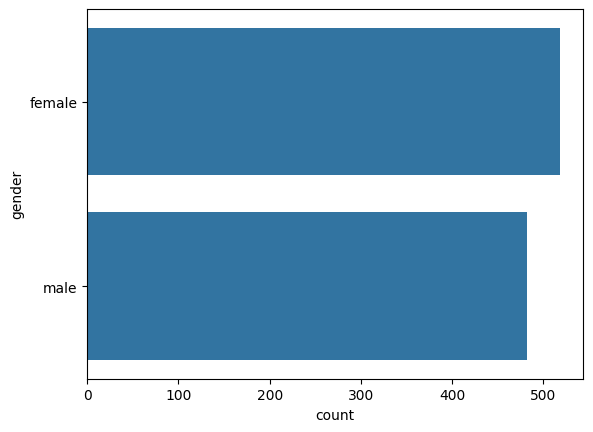

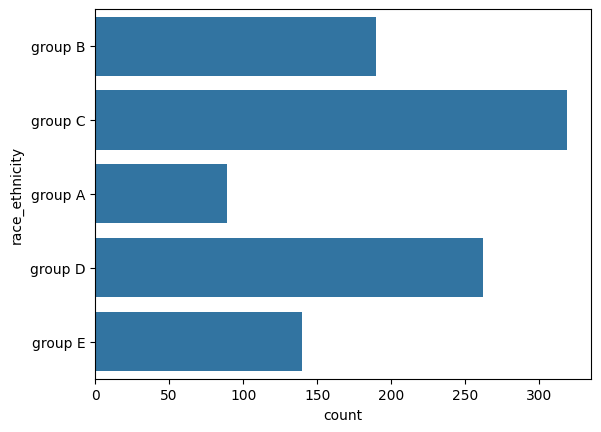

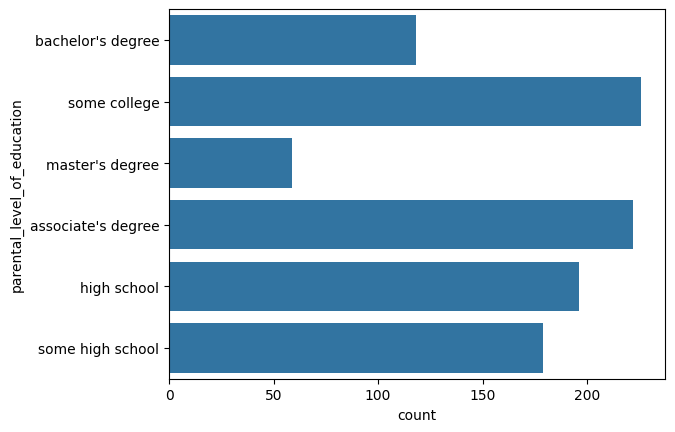

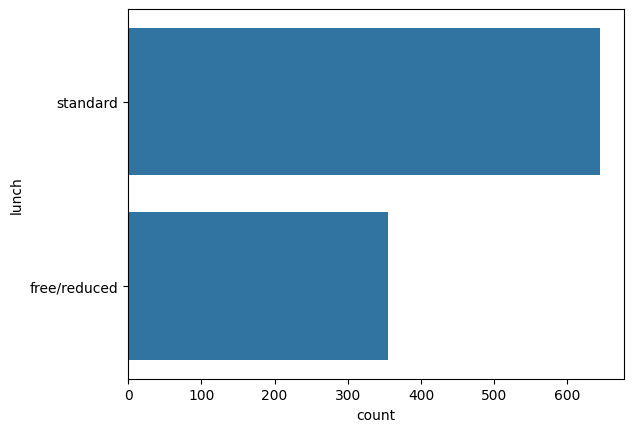

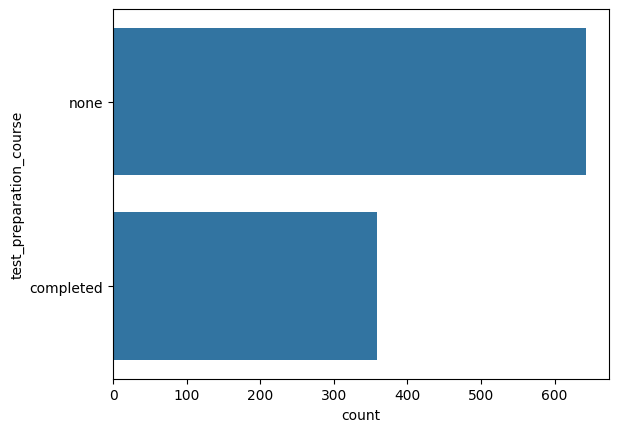

In [41]:
for i in category:
    sns.countplot(df[i])
    plt.show()

['gender',
 'race_ethnicity',
 'parental_level_of_education',
 'lunch',
 'test_preparation_course']

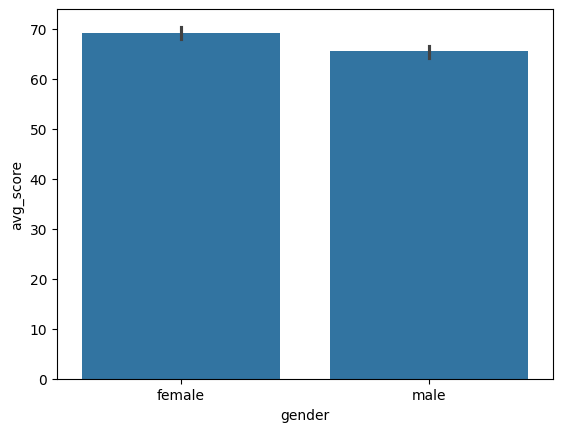

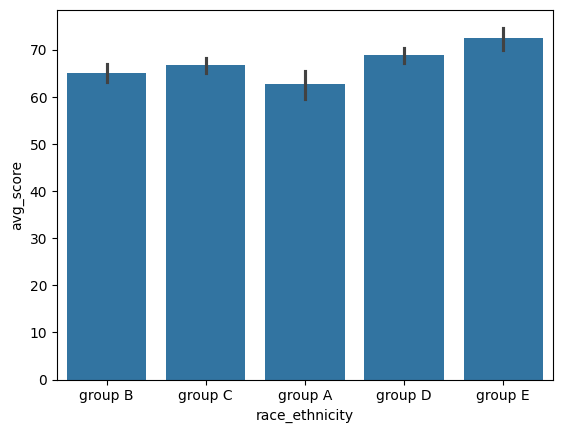

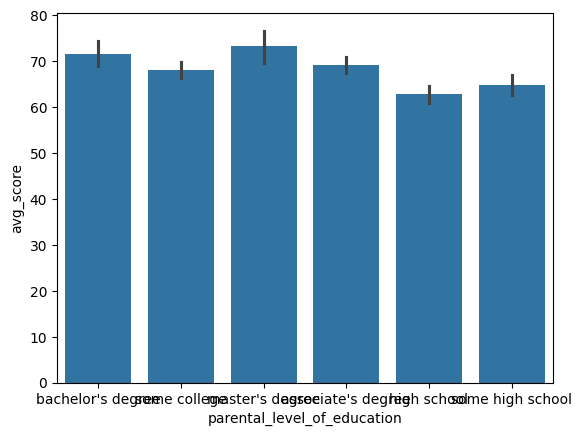

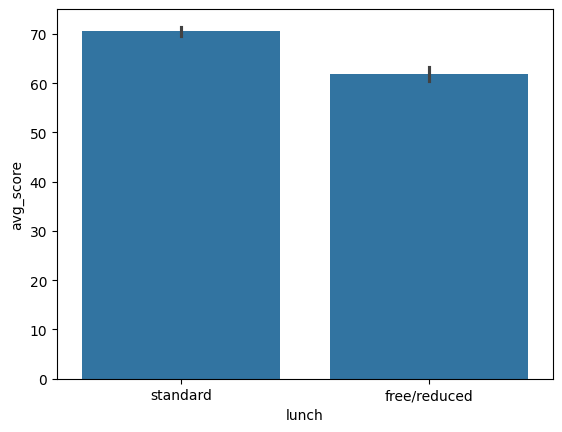

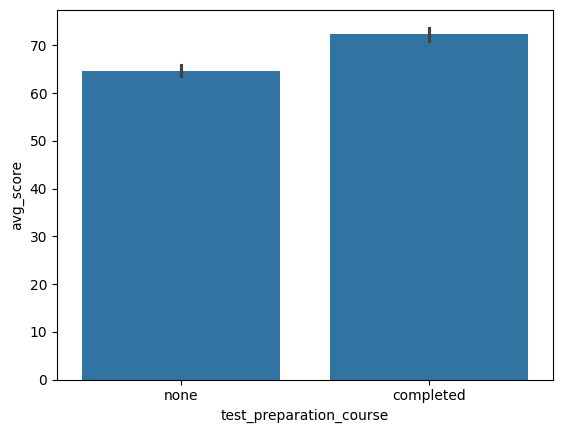

In [44]:
for i in category:
    sns.barplot(x=df[i],y=df['avg_score'])
    plt.show()

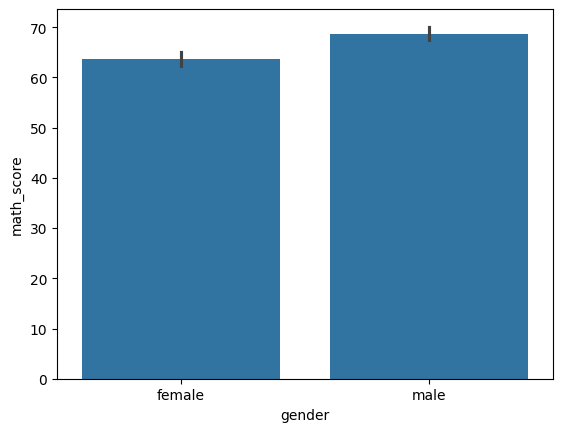

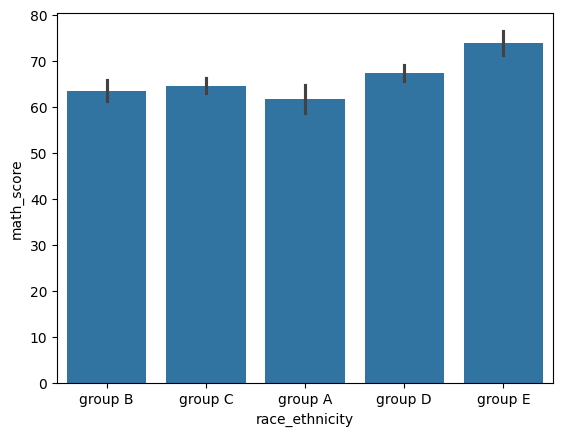

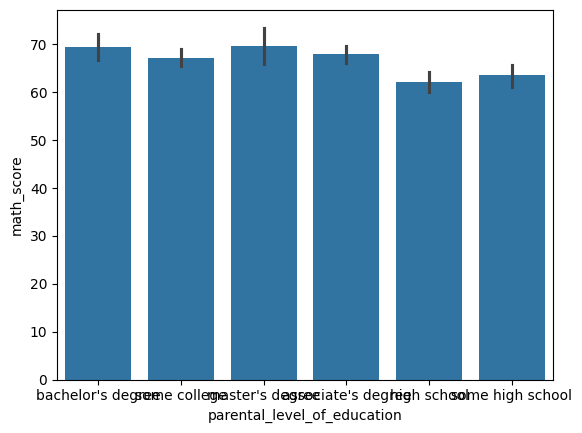

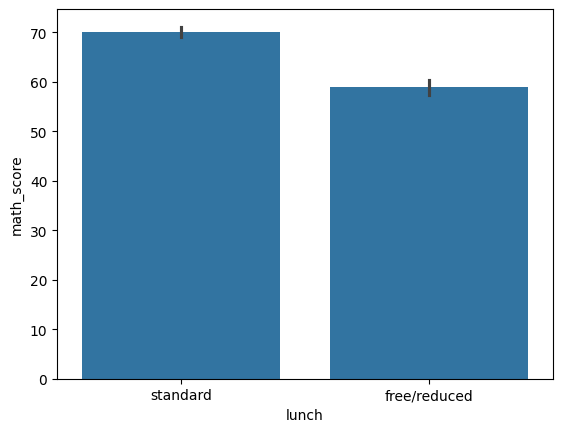

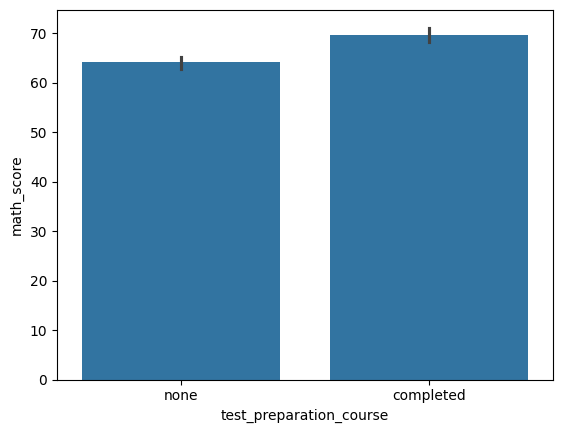

In [45]:
for i in category:
    sns.barplot(x=df[i],y=df['math_score'])
    plt.show()

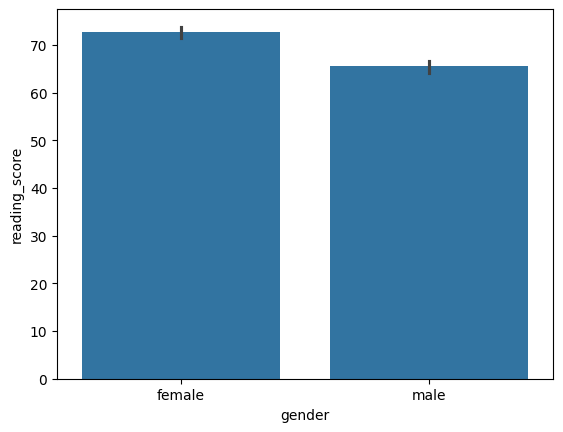

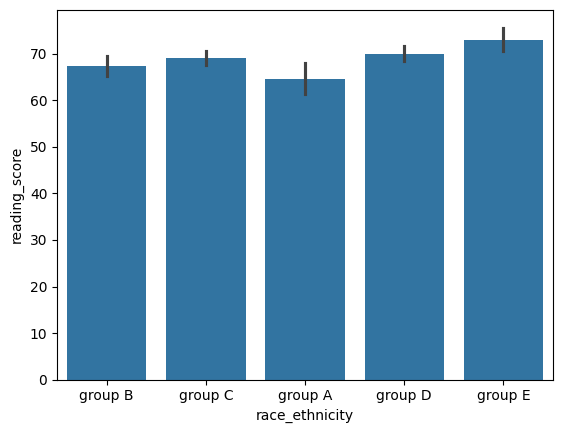

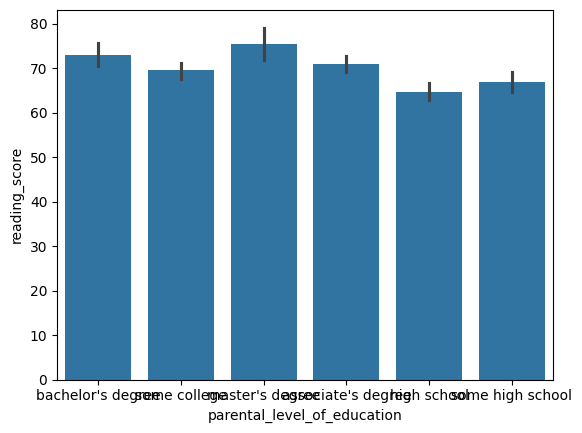

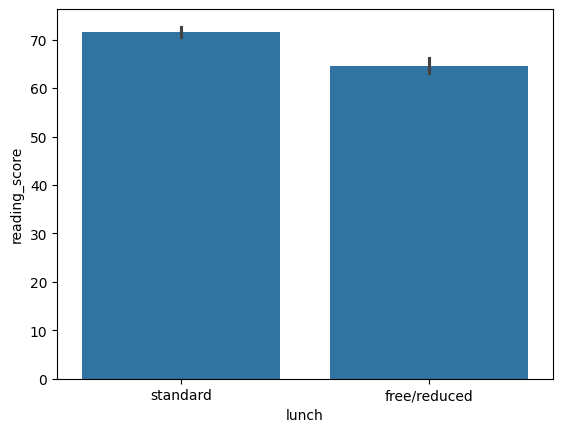

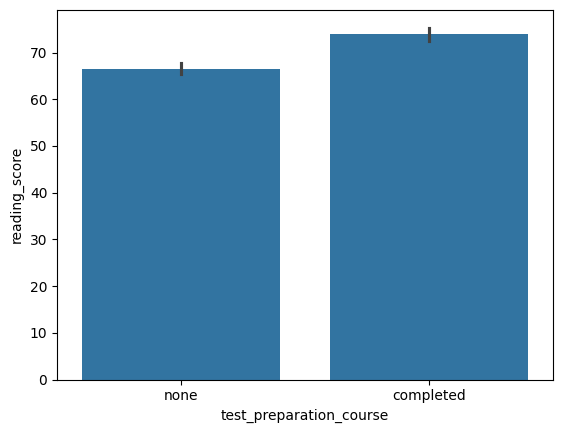

In [46]:
for i in category:
    sns.barplot(x=df[i],y=df['reading_score'])
    plt.show()

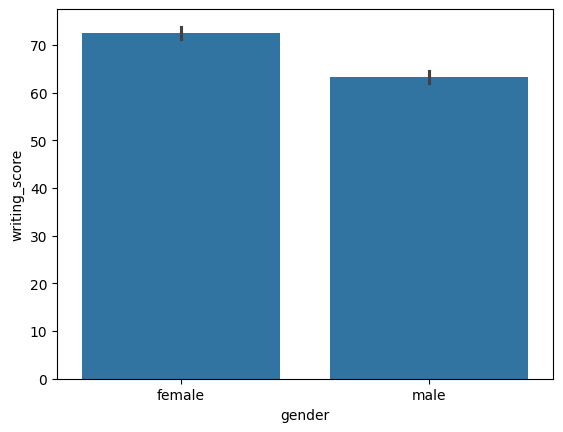

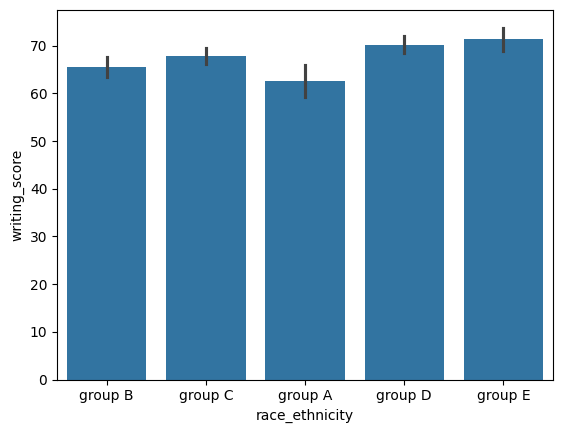

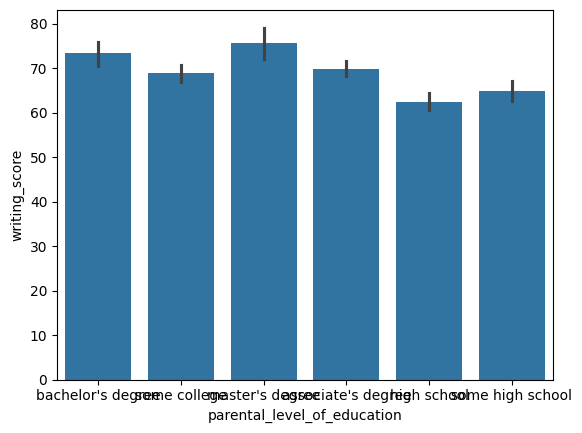

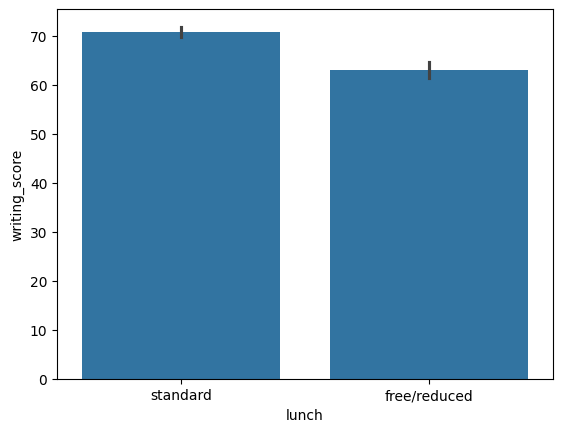

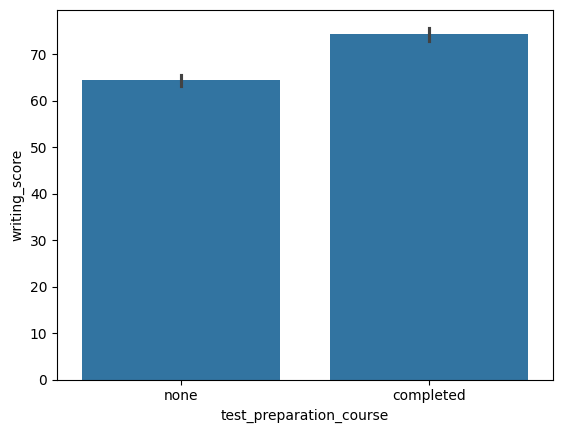

In [47]:
for i in category:
    sns.barplot(x=df[i],y=df['writing_score'])
    plt.show()

### Students with a test preperation course , standard lunch, e category and high parential education generally score more.
### Female students score more in reading and writing were as male students had scored more in math, but on an avg female students score higher.

In [69]:
# no of students failed
num=[i for i in df.columns if df[i].dtype=='int']
for i in num:
    if i not in ('Total_score','avg_score'):
        print(f'{i} : {len(df[df[i]<35])}')


math_score : 22
reading_score : 15
writing_score : 17


### number of students who failed in math were more compared to other subjects

In [89]:
for i in num:
    if i not in ('Total_score','avg_score'):
        print(f"{i} : {df[df[i]<35]['math_score'].groupby(df['gender']).count()}\n.............................\n")


math_score : gender
female    18
male       4
Name: math_score, dtype: int64
.............................

reading_score : gender
female    7
male      8
Name: math_score, dtype: int64
.............................

writing_score : gender
female    9
male      8
Name: math_score, dtype: int64
.............................



In [87]:
df[df['math_score']<35]['math_score'].groupby(df['gender']).count()

gender
female    18
male       4
Name: math_score, dtype: int64

### Female students failed more than male students